In [321]:
# Estimate beta given k_mean and gamma
import EoN
import networkx as nx
from collections import defaultdict
import matplotlib.pyplot as plt
import random
import pandas as pd
import numpy as np
from collections import defaultdict
from scipy.optimize import root_scalar

N = 1000000 # number of nodes
k_mean = 10. # degree
beta = 0.3 # edge transmission rate
G = nx.fast_gnp_random_graph(N, k_mean / (N - 1))

gamma = 1/7

def R0_root_fn(beta, target_R0, G, gamma):
    est = EoN.estimate_R0(G, beta, gamma)
    return est - target_R0

In [322]:
target_R0 = 4.0

sol = root_scalar(
    R0_root_fn,
    args=(target_R0, G, gamma),
    bracket=[1e-4, 1.0], 
    method='bisect'
)

beta_star = sol.root
print("beta* =", beta_star)

beta* = 0.09530716279514766


In [323]:
# Generate SEIR epidemic on network
import EoN
import networkx as nx
from collections import defaultdict
import matplotlib.pyplot as plt
import random
import pandas as pd
import numpy as np
from collections import defaultdict
from scipy.optimize import root_scalar
N = 1000000 # number of nodes
k_mean = 10. # degree
beta = beta_star # edge transmission rate
gamma = 1/7
G = nx.fast_gnp_random_graph(N, k_mean / (N - 1))

H = nx.DiGraph()
H.add_node('S')
H.add_edge('E', 'I', rate = 1)
H.add_edge('I', 'R', rate = gamma)

J = nx.DiGraph()
J.add_edge(('I', 'S'), ('I', 'E'), rate = beta)
IC = defaultdict(lambda: 'S')
for node in range(500):
    IC[node] = 'I'

return_statuses = ('S', 'E', 'I', 'R')

sim_10 = EoN.Gillespie_simple_contagion(G, H, J, IC, return_statuses, return_full_data = True, tmax = float('Inf'))

In [324]:
# Estimate R0
R0 = EoN.estimate_R0(G, tau = beta, gamma = gamma)
R0

np.float64(4.001456343866455)

In [325]:
# Get true Rt at each time point
seir_dat = pd.DataFrame(sim_10.summary()[1])
seir_dat['time'] = sim_10.summary()[0]
#seir_dat.head()

seir_dat['true_rt'] = seir_dat['S'] * R0 / N
#seir_dat.head()

seir_dat.to_csv("seir_deg10_r04a.csv")

In [326]:
seir_dat

,S,E,I,R,time,true_rt
0,999500,0,500,0,0.000000,3.999456
1,999499,1,500,0,0.000067,3.999452
2,999498,2,500,0,0.001493,3.999448
3,999498,2,499,1,0.003024,3.999448
4,999497,3,499,1,0.006003,3.999444
...,...,...,...,...,...,...
2939338,19886,0,4,980110,107.912267,0.079573
2939339,19886,0,3,980111,108.697096,0.079573
2939340,19886,0,2,980112,118.428089,0.079573
2939341,19886,0,1,980113,118.864232,0.079573


In [327]:
# Get paired transmission data
infection_time = {}

for t, u, v in sim_10.transmissions():
    infection_time[v] = t

rows = [] 

for _, u, v in sim_10.transmissions():
    if u in infection_time and v in infection_time:
        rows.append({
            "infector": u,
            "infectee": v,
            "etime_infector": infection_time[u],
            "etime_infectee": infection_time[v],
        })
        
df_pairs = pd.DataFrame(rows)
df_pairs.head()
df_pairs.to_csv("cori_pairs_deg10_r04a.csv")


In [328]:
# Get incidence data
summary = sim_10.summary()

t = summary[0]
S = summary[1]['S']
E = summary[1]['E']
I = summary[1]['I']
R = summary[1]['R']

incidence = -np.diff(S)
incidence_times = t[1:]

dt = 1
t_bins = np.arange(0, t[-1] + dt, dt)

incidence_binned = np.zeros(len(t_bins)-1)

for ti, di in zip(incidence_times, incidence):
    if di > 0:
        idx = int(ti // dt)
        incidence_binned[idx] += di

incidence_df = pd.DataFrame(incidence_binned)
incidence_df.to_csv("incidence_deg10_r04a.csv")

In [329]:
incidence_df

,0
0,482.0
1,613.0
2,922.0
3,1407.0
4,2179.0
...,...
116,0.0
117,0.0
118,0.0
119,0.0


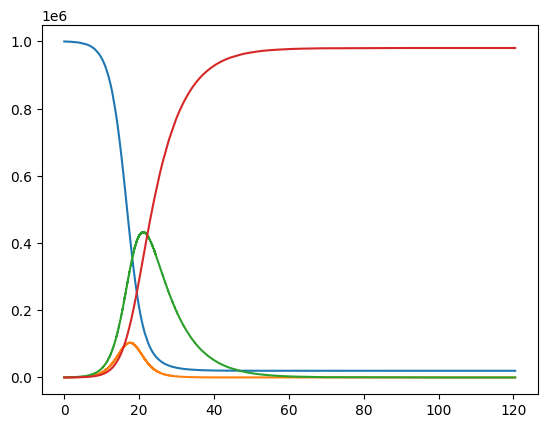

In [330]:
# Plot
plt.plot(t, S, label = 'Susceptible')
plt.plot(t, E, label = 'Exposed')
plt.plot(t, I, label = 'Infected')
plt.plot(t, R, label = 'Recovered')

In [331]:
# Get individual histories 
rows = []

for node in sim_10.G.nodes():
    times, states = sim_10.node_history(node)
    
    etime = np.nan
    itime = np.nan
    rtime = np.nan
    
    for t, s in zip(times, states):
        if s == 'E' and pd.isna(etime):
            etime = t
        elif s == 'I' and pd.isna(itime):
            itime = t
        elif s == 'R' and pd.isna(rtime):
            rtime = t
    
    rows.append({
        "node": node,
        "etime": etime,
        "itime": itime,
        "rtime": rtime
    })

df1 = pd.DataFrame(rows)
df1.to_csv("eon_dsa_deg10_r04a.csv")

In [332]:
sim_10.node_history(3202)

([0, 14.931847235106181, 14.932335810760264, 22.01643141904554],
 ['S', 'E', 'I', 'R'])

In [ ]:
# Number of events in the sample (this csv comes from R)
sampdf = pd.read_csv("sampdeg10_r04_700.csv")

In [ ]:
# match ids from sample back to the original network
ids = sampdf["id"]

events = []

for node in sampdf["id"]:
    
    times, states = sim_10.node_history(node)

    for i in range(len(times)):

        events.append({
            "time": times[i],
            "node": node,
            "state": states[i]
        })

events_df = pd.DataFrame(events)

In [342]:
events_df.head()

,time,node,state
0,0.000000,277276,S
1,11.115727,277276,E
2,12.174387,277276,I
3,14.366068,277276,R
4,0.000000,35899,S


In [ ]:
# add last state for each node
events_df = events_df.sort_values(["node","time"])
events_df["prev_state"] = events_df.groupby("node")["state"].shift()
events_df.head()

,time,node,state,prev_state
1709,0.000000,1608,S,NaN
1710,14.588178,1608,E,S
1711,14.947144,1608,I,E
1712,21.581568,1608,R,I
2059,0.000000,2758,S,NaN


In [ ]:
# add up transitions and sort by kind, then bin into single unit times
counts = (
    events_df
    .loc[events_df["prev_state"].notna()]
    .assign(
        time_bin = lambda df: df["time"].astype(int),
        transition = lambda df: df["prev_state"] + "-" + df["state"]
    )
    .pivot_table(
        index = "time_bin",
        columns = "transition",
        aggfunc = "size",
        fill_value = 0
    )
)
counts = counts.reindex(range(0, int(events_df["time"].max()) + 1), fill_value = 0).reset_index()


In [345]:
counts_df = pd.DataFrame(counts)
counts_df.to_csv("counts_deg10_r04_700.csv")